# Modèles simples de réseaux à commutation de paquets

---

__Objectifs__ : Modéliser les réseaux à commutation de paquets par des modèles de réseaux de files d’attentes
simples. Etudier l’impact de la durée de la simulation sur les intervalles de confiance. Valider les résultats
obtenus par simulation.

---

Une source de trafic génère des paquets dont l’inter-arrivée est exponentiellement distribuée de
moyenne 1/$\lambda$. Les paquets sont envoyés sans mise en place de mécanismes de contrôle (ni contrôle
de flux, ni contrôle de congestion).

Nous nous intéressons au dimensionnement des files de sortie d’un noeud de commutation. Dans la
première partie, nous supposons que ces noeuds de commutations n’ont aucune limitation de
capacité. Les tailles des datagrammes et des trames sont considérées infinies.

### Simulation de files M/M/1, M/D/1
La taille des paquets est exponentiellement distribuée de moyenne (100000 bits/8 $\mu$). La capacité du
lien de sortie des noeuds de commutation est de 100Kbps.

1) Observer, le temps de réponse (de l’émission du premier bit du paquet par la source jusqu’à la
réception du dernier bit du paquet par la destination) et le nombre de paquets pour $\lambda=20$ et $\mu=33$ et
pour une durée de simulation de 10sec :
    - a. Tracer le temps de réponse.
    - b. Tracer également les nombres, instantané et moyen, de paquets dans la file en fonction du
temps.

0.3642857142857143
1.0499999999999998
4.950000000000002
---
0.0367965367965368
0.05303030303030302
0.16666666666666674
Lancement de la simulation
Traitement du temps de reponse (tr)
    nb_pkt   tr_instant      tr_mean     int_conf    borne_inf    borne_sup
       165     0.004320     0.048980     0.006392     0.042588     0.055372
Traitement de la taille des files d'attente (fa)
             fa_instant      fa_mean     int_conf    borne_inf    borne_sup
                      2     0.819445     0.705672     0.113773     1.525117
Affichage des graphes tr & fa

test
Affichage des graphes tr & fa


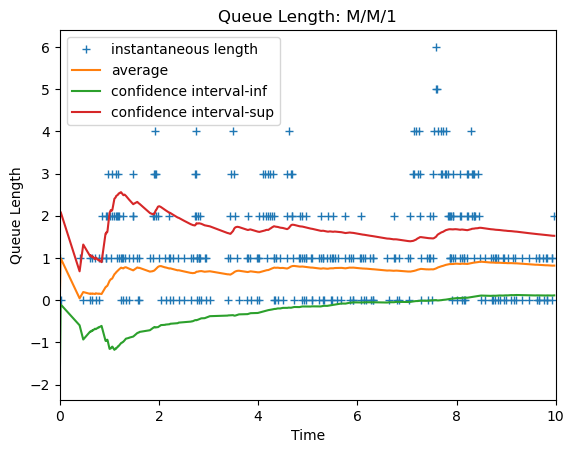

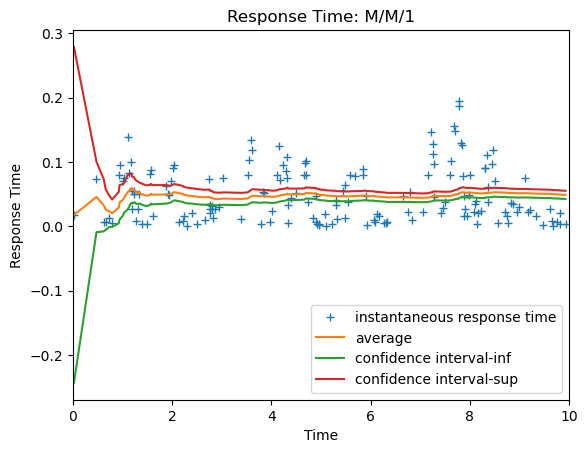

In [ ]:
# ns doit être installé pour lancer ce script (apt install ns2)
# version recommandée de python: 3.8
# Ce script permet de lancer une simulation de file d'attente M/M/1
import subprocess
import os
from MM1.utils import plot_length, plot_response

plot = True # True pour afficher les graphes de longueur de file d'attente et de temps de réponse
cwd = os.getcwd()
os.chdir(f"{cwd}/MM1")
lambda_val = 20.0
mu = 33.0
duration = 10  # sec
mm1 = subprocess.run(["sh" , "sim_mm1.sh", str(lambda_val), str(mu), str(duration)], capture_output=True, text=True)
print(mm1.stdout)

if (plot):
    print("Affichage des graphes tr & fa")
    plot_length(duration, "Queue Length: M/M/1")
    plot_response(duration, "Response Time: M/M/1")

os.chdir("..")



2) Trouver par simulation le nombre moyen de paquets dans la file d’émission ainsi que le temps
moyen de réponse, pour une charge variant de 0.3, 0.6 et 0.9.
Observer le temps de réponse moyen, le nombre moyen de clients ainsi que les intervalles de
confiance associés en fonction de la durée de la simulation.



Lancement de la simulation
Traitement du temps de reponse (tr)
    nb_pkt   tr_instant      tr_mean     int_conf    borne_inf    borne_sup
    106734     0.045920     0.046941     0.000269     0.046673     0.047210
Traitement de la taille des files d'attente (fa)
             fa_instant      fa_mean     int_conf    borne_inf    borne_sup
                      2     0.501033     0.018438     0.482595     0.519472
Affichage des graphes tr & fa

Affichage des graphes tr & fa pour load = 0.3


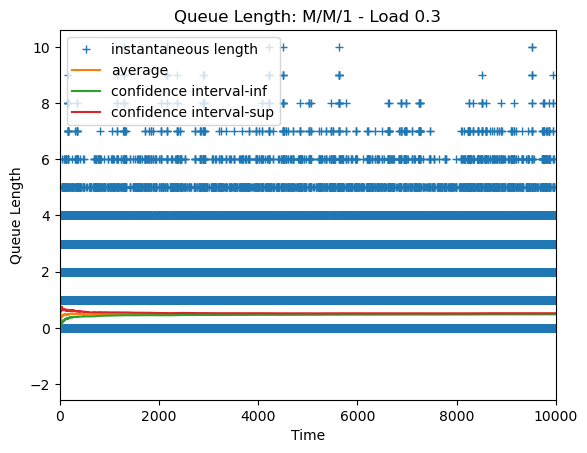

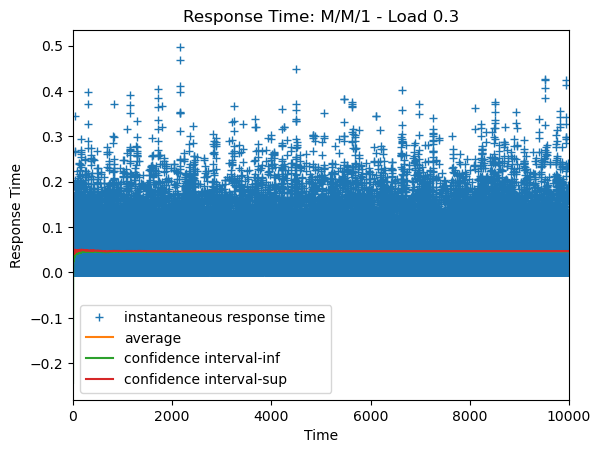


Lancement de la simulation
Traitement du temps de reponse (tr)
    nb_pkt   tr_instant      tr_mean     int_conf    borne_inf    borne_sup
    213237     0.084160     0.080487     0.000336     0.080152     0.080823
Traitement de la taille des files d'attente (fa)
             fa_instant      fa_mean     int_conf    borne_inf    borne_sup
                      1     1.716299     0.044229     1.672070     1.760528
Affichage des graphes tr & fa

Affichage des graphes tr & fa pour load = 0.6


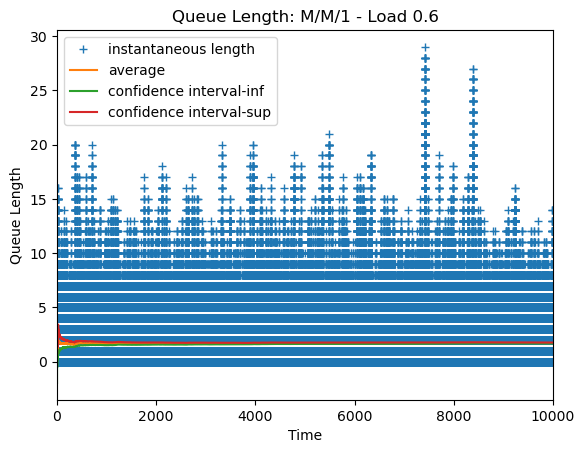

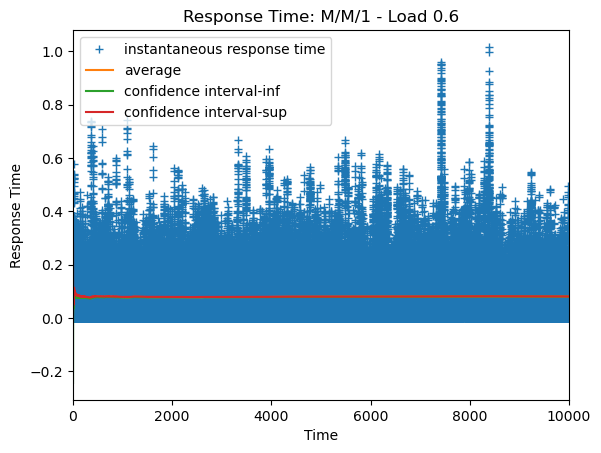


Lancement de la simulation
Traitement du temps de reponse (tr)
    nb_pkt   tr_instant      tr_mean     int_conf    borne_inf    borne_sup
    319237     0.120148     0.301681     0.001045     0.300637     0.302726
Traitement de la taille des files d'attente (fa)
             fa_instant      fa_mean     int_conf    borne_inf    borne_sup
                      6     9.630853     0.199827     9.431026     9.830680
Affichage des graphes tr & fa

Affichage des graphes tr & fa pour load = 0.9


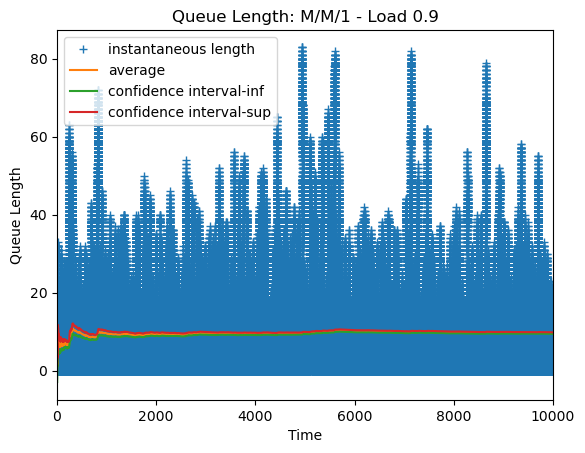

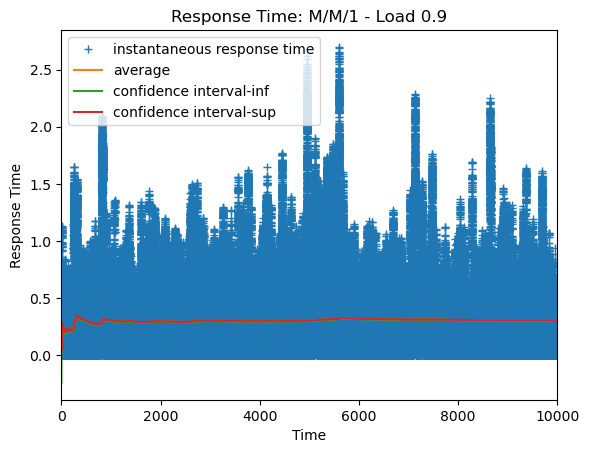

In [3]:
# ns doit être installé pour lancer ce script (apt install ns2)
# version recommandée de python: 3.8
# Ce script permet de lancer une simulation de file d'attente M/M/1
import subprocess
import os
from MM1.utils import plot_length, plot_response

for load in [0.3, 0.6, 0.9]:
    print()
    plot = True # True pour afficher les graphes de longueur de file d'attente et de temps de réponse
    cwd = os.getcwd()
    os.chdir(f"{cwd}/MM1")
    mu = 33.0
    lambda_val = load * mu
    duration = 10000  # sec
    mm1 = subprocess.run(["sh" , "sim_mm1.sh", str(lambda_val), str(mu), str(duration)], capture_output=True, text=True)
    print(mm1.stdout)

    if (plot):
        print("Affichage des graphes tr & fa pour load =", load)
        plot_length(duration, "Queue Length: M/M/1 - Load " + str(load))
        plot_response(duration, "Response Time: M/M/1 - Load " + str(load))

    os.chdir("..")


3) Reprendre les deux premières questions, pour des paquets de taille constante et comparer les résultats.



Lancement de la simulation
Traitement du temps de reponse (tr)
    nb_pkt   tr_instant      tr_mean     int_conf    borne_inf    borne_sup
     99493     0.053461     0.036854     0.000082     0.036772     0.036936
Traitement de la taille des files d'attente (fa)
             fa_instant      fa_mean     int_conf    borne_inf    borne_sup
                      0     0.366681     0.012139     0.354542     0.378820
Affichage des graphes tr & fa

Affichage des graphes tr & fa pour load = 0.3


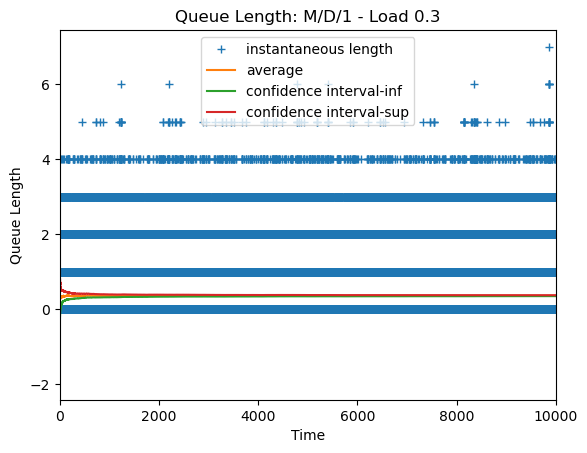

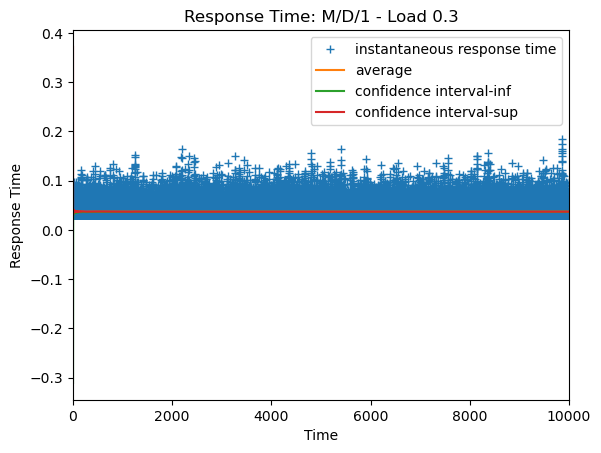


Lancement de la simulation
Traitement du temps de reponse (tr)
    nb_pkt   tr_instant      tr_mean     int_conf    borne_inf    borne_sup
    198729     0.034393     0.053427     0.000138     0.053289     0.053565
Traitement de la taille des files d'attente (fa)
             fa_instant      fa_mean     int_conf    borne_inf    borne_sup
                      3     1.061756     0.023622     1.038134     1.085378
Affichage des graphes tr & fa

Affichage des graphes tr & fa pour load = 0.6


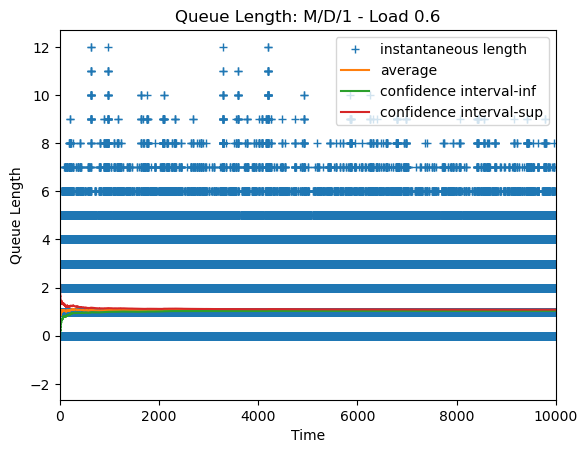

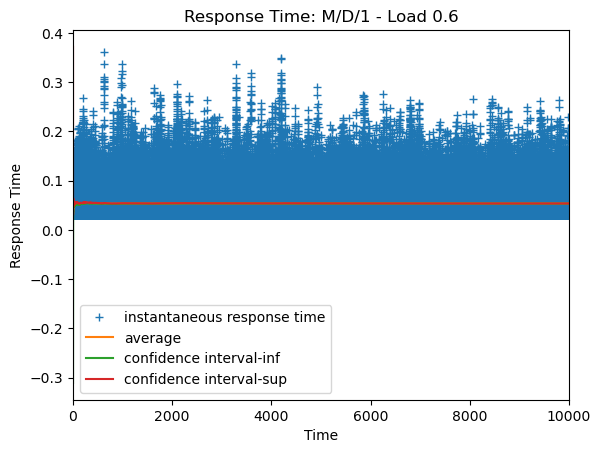


Lancement de la simulation
Traitement du temps de reponse (tr)
    nb_pkt   tr_instant      tr_mean     int_conf    borne_inf    borne_sup
    297737     0.169155     0.172078     0.000553     0.171526     0.172631
Traitement de la taille des files d'attente (fa)
             fa_instant      fa_mean     int_conf    borne_inf    borne_sup
                      5     5.123476     0.100368     5.023108     5.223844
Affichage des graphes tr & fa

Affichage des graphes tr & fa pour load = 0.9


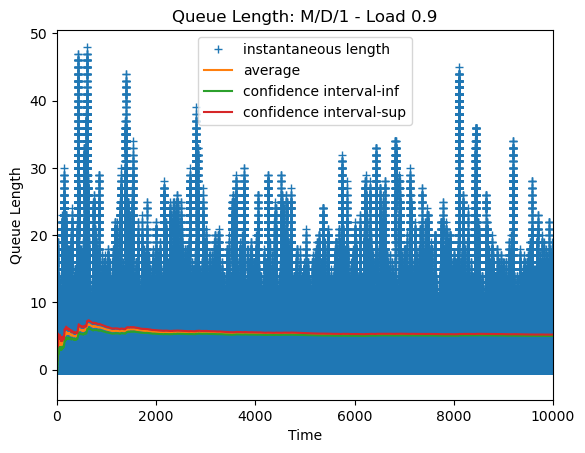

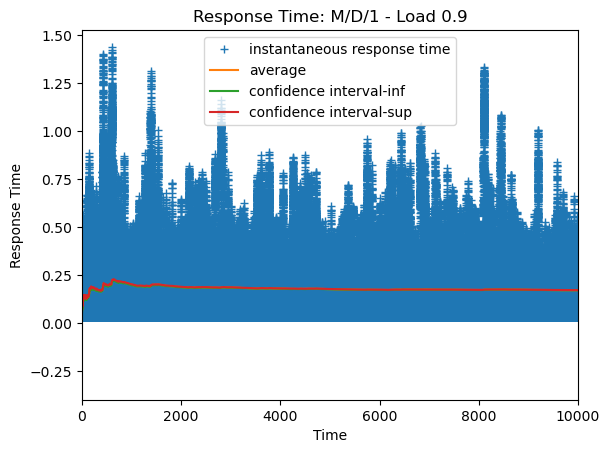

In [4]:
import subprocess
import os
from MM1.utils import plot_length, plot_response

for load in [0.3, 0.6, 0.9]:
    print()
    plot = True # True pour afficher les graphes de longueur de file d'attente et de temps de réponse
    mu = 33.0
    lambda_val = load * mu
    duration = 10000  # sec

    os.chdir(f"{os.getcwd()}/MM1")

    md1 = subprocess.run(["sh" , "sim_md1.sh", str(lambda_val), str(mu), str(duration)], capture_output=True, text=True)
    print(md1.stdout)

    if (plot):
        print("Affichage des graphes tr & fa pour load =", load)
        plot_length(duration, "Queue Length: M/D/1 - Load " + str(load))
        plot_response(duration, "Response Time: M/D/1 - Load " + str(load))

    os.chdir("..")

### Simulation de files de taille finie
Dans le modèle précédent, les buffers sont considérés de très grande taille afin d’éviter les pertes.
Utiliser les buffers de capacité limitée, peut être modélisé par une file M/M/1/K.
1) Déterminer par simulation la probabilité de rejet de paquets pour $K=2$,
$\lambda=20$ et $\mu=33$.


2) Tracer le taux de rejet en fonction de K.


Capa. file	Tx analy.	Tx simu.
1	0.377358490566038	0.99324935072952
2	0.186133085155886	0.131494415465771
3	0.101372327888795	0.131538873746583
4	0.0578816544457995	0.0488060256020536
5	0.0338909047328468	0.0484095410607574
6	0.0201265442063919	0.0184638548249698
7	0.0120509097207096	0.0181474129232575
8	0.00725062610912116	0.00729986764725948
9	0.00437509329904079	0.00678754594795099
10	0.00264455945738175	0.00265787341700186
11	0.00160019856795465	0.000348189415041783
12	0.000968877679563206	0.00100211508360566
13	0.000586853993834798	0.000412614205717654
14	0.000355542631649355	0.000323019773424702
15	0.000215433961025397	0.000213991769547325
16	0.000130548991720608	9.92890196982323e-05
17	7.91143414685446e-05	0.000115184814034118
18	4.79457868298142e-05	3.86451026993604e-05
19	2.90572082782425e-05	3.92646516047463e-05
20	1.76101191377836e-05	1.64635250602291e-05

-----------------------
1	0.377358490566038	0.185953946398561
2	0.186133085155886	0.0584441112776945
3	0.101372327888795	

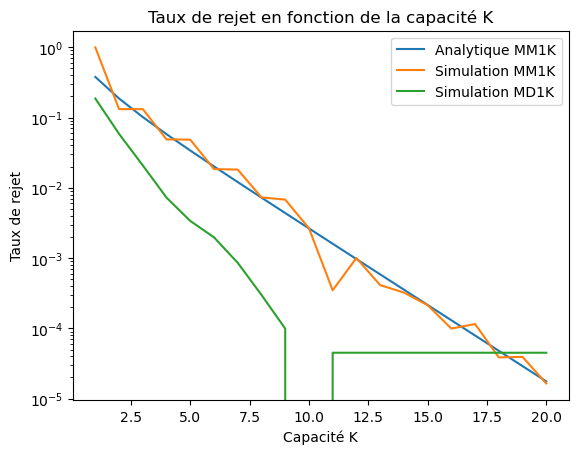

In [2]:
import subprocess
import os
from concurrent.futures import ThreadPoolExecutor, as_completed
import matplotlib.pyplot as plt

# Déplacer le répertoire de travail
os.chdir("MM1K")

# Valeurs initiales
lambda_val, mu, duration1, duration2 = 20, 33, 10000, 20000  # msec

def run_script(script_name, lambda_val, mu, duration):
    result = subprocess.run(["perl", script_name, str(lambda_val), str(mu), str(duration)], capture_output=True, text=True)
    return result.stdout

# Utilisation de ThreadPoolExecutor pour exécuter les scripts en parallèle
with ThreadPoolExecutor() as executor:
    futures = []
    futures.append(executor.submit(run_script, "rejet.pl", lambda_val, mu, duration1))
    futures.append(executor.submit(run_script, "rejetMD1K.pl", lambda_val, mu, duration2))
    results = [future.result() for future in as_completed(futures)]


print("Capa. file\tTx analy.\tTx simu.")
print(results[0])
print("-----------------------")
print(results[1])

lines, lines2 = list(map(lambda listi : list(filter(lambda y: y.strip() != "", listi)) ,list(map(lambda x: x.replace("\t", " ").split("\n"), results))))

# Traiter la sortie du premier script
x_rej, y1_rej, y2_rej = zip(*[map(float, line.split(" ")) for line in lines])

# Traiter la sortie du deuxième script
x_rej2, y1_rej2, y2_rej2 = zip(*[map(float, line.split(" ")) for line in lines2])

# Plot des résultats 
plt.xlabel("Capacité K")
plt.ylabel("Taux de rejet")
plt.yscale("log")
plt.title("Taux de rejet en fonction de la capacité K")
plt.plot(x_rej, y1_rej, label="Analytique MM1K")
plt.plot(x_rej, y2_rej, label="Simulation MM1K")
plt.plot(x_rej2, y2_rej2, label="Simulation MD1K")
plt.legend()
plt.show()

# Revenir au répertoire précédent
os.chdir("..")


3) Reprendre la question précédente, pour des paquets de taille constante.


### Simulation d’un système composé de deux noeuds de commutation.
Trouver le temps de réponse du système dans le cas où la source et la destination sont séparées par
un noeud de commutation de même caractéristiques (Pour des paquets de taille exponentiellement
distribuée et pour des paquets de taille constante).

1) Trouver la loi d'arrivée des paquets dans la 2ème file lorsque la première est suit une loi exponentielle de paramètre $\lambda$

2) Observer ce résultat par simulation

Theoric Mean Length : 9.9999999999999964

Theoric Response Time : 0.3333333333333332

8999.977185 269914 0.917175999999017 0.330531628068086 0.00125970408804218 0.329271923980044 0.331791332156129
8999.996545 269913 0.158079999999245 0.143113691616555 0.000239710626882158 0.142873980989673 0.143353402243437



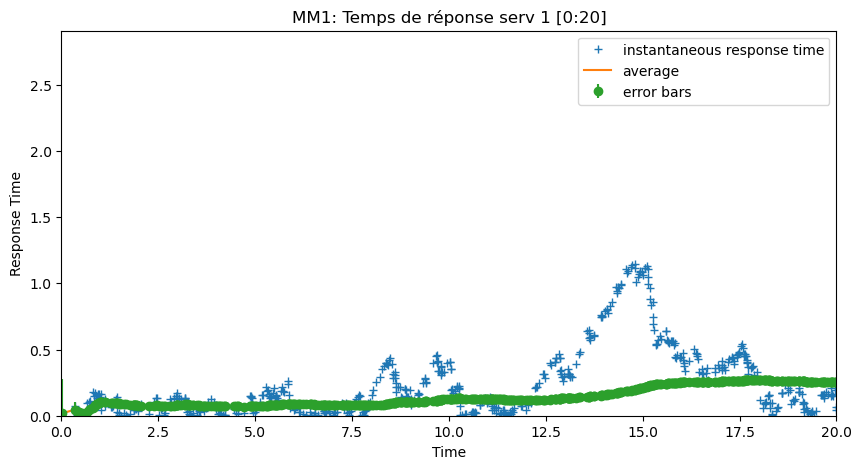

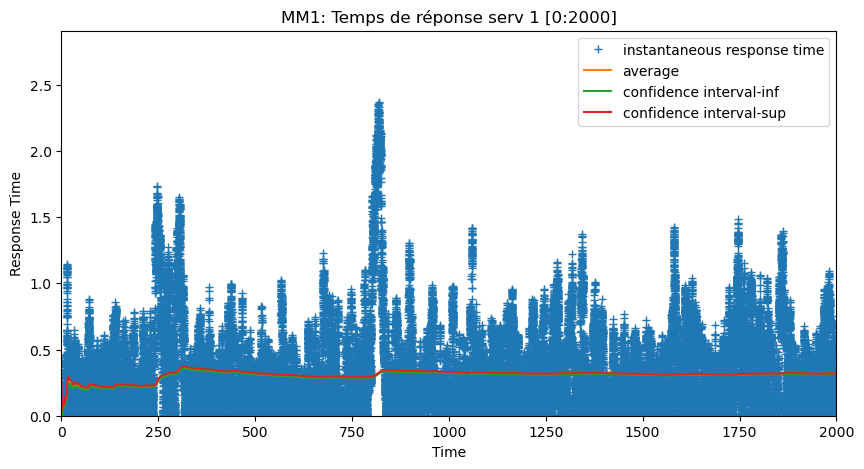

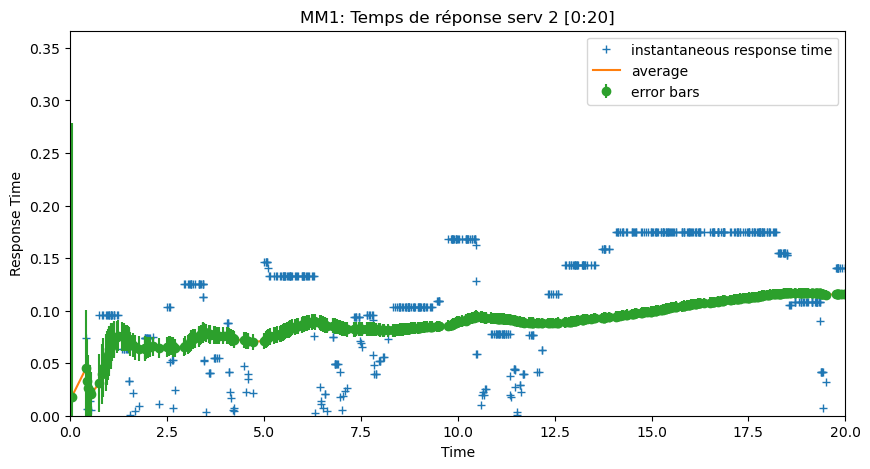

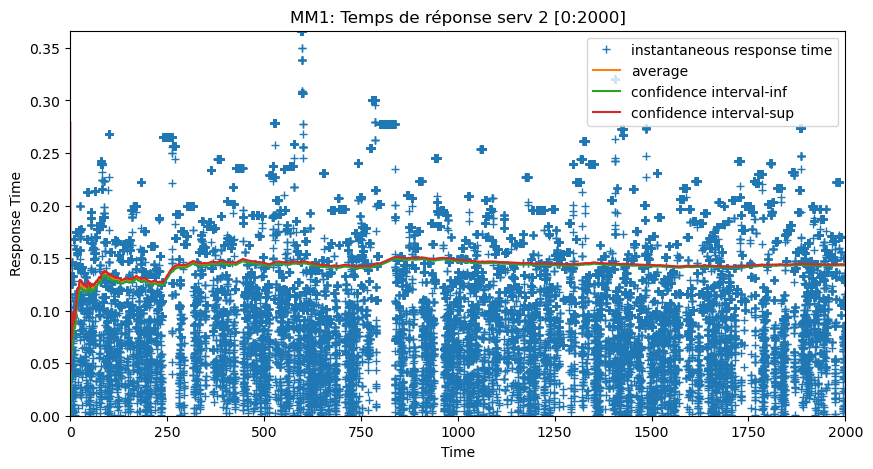

In [2]:
from NET_MM1.utils import plot_response
import os
import subprocess


mm1 = subprocess.run(["sh", "./sim"], cwd="./NET_MM1", capture_output=True, text=True)

if mm1.returncode != 0:
    print(mm1.stderr)
else:
    print(mm1.stdout)
    
    
os.chdir("NET_MM1/trace_Response")

# Plot data for avr_response1.out
plot_response('avr_response1.out', 20, "MM1: Temps de réponse serv 1 [0:20]", yerr_idx=5)
plot_response('avr_response1.out', 2000, "MM1: Temps de réponse serv 1 [0:2000]", confidence_intervals=(5, 6))

# Plot data for avr_response2.out
plot_response('avr_response2.out', 20, "MM1: Temps de réponse serv 2 [0:20]", yerr_idx=5)
plot_response('avr_response2.out', 2000, "MM1: Temps de réponse serv 2 [0:2000]", confidence_intervals=(5, 6))

os.chdir("../..")

3) Observer par simulation le comportement de la deuxième file dans le cas d'une première file MD1. Expliquer ce comportement.

/home/ave9761/git_perso/2a/simu_reseaux/tp1
Theoric Mean Length : 5.4545454545454524

Theoric Response Time : 0.18181818181818174

8999.984901 270701 0.0303199999998469 0.189326209207811 0.000649109685276846 0.188677099522534 0.189975318893088
8999.98288 270700 0.0303199999998469 0.0303200000000003 0 0.0303200000000003 0.0303200000000003



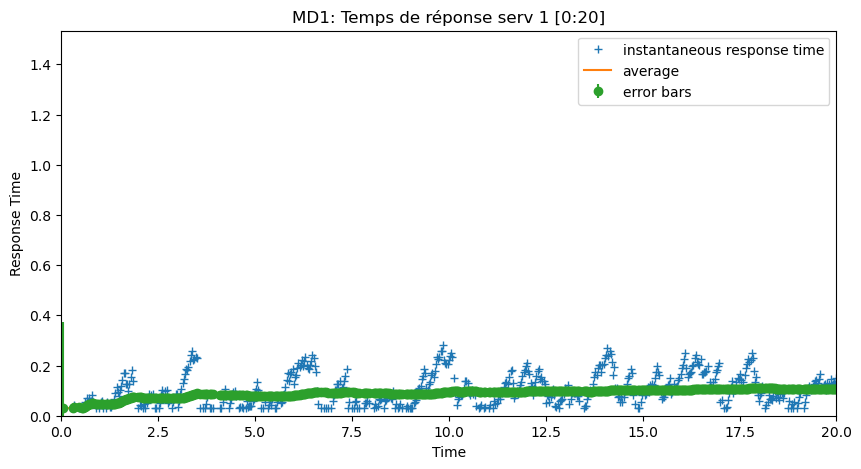

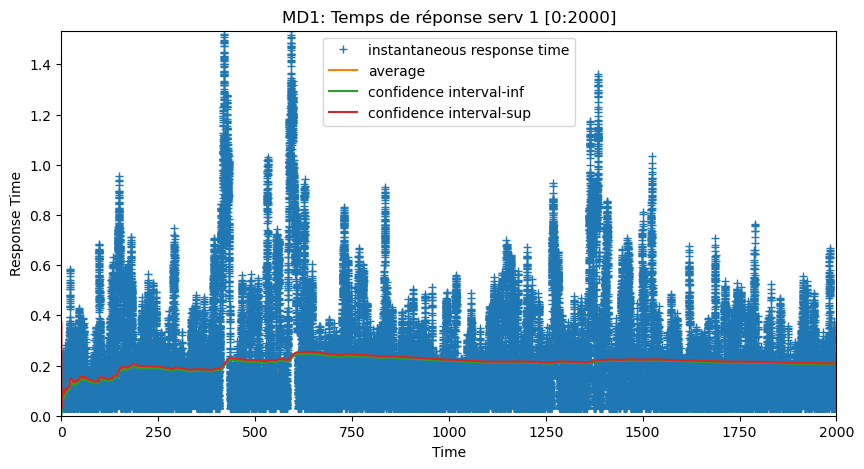

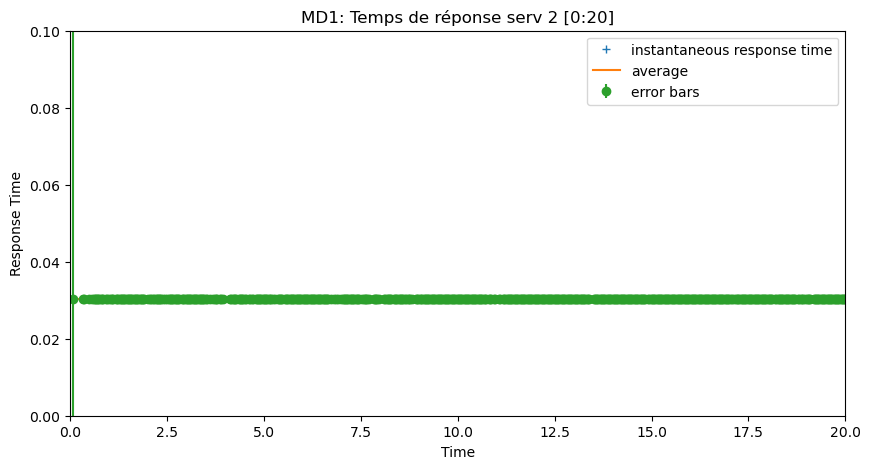

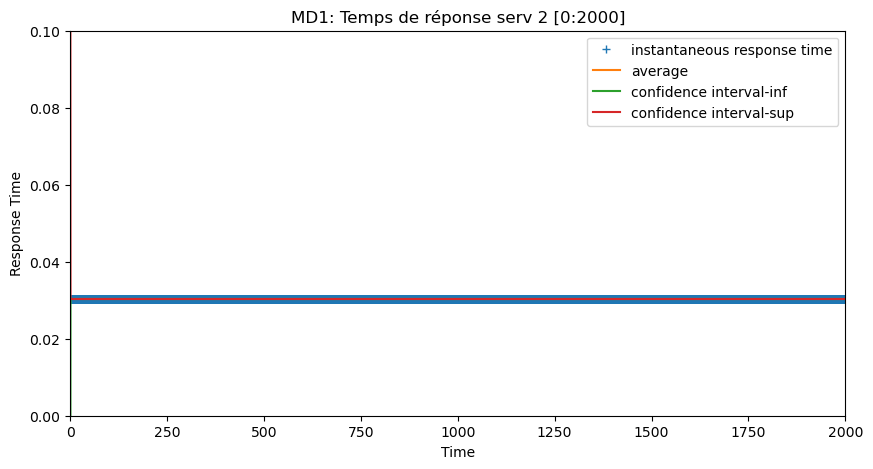

In [3]:
from NET_MM1.utils import plot_response
import subprocess

print(os.getcwd())

md1 = subprocess.run(["sh", "./run.simu"], cwd="./NET_MD1", capture_output=True, text=True)

if md1.returncode != 0:
    print(md1.stderr)
else:
    print(md1.stdout)
    
    
os.chdir("NET_MD1/trace_Response")

# Plot data for avr_response1.out
plot_response('avr_response1.out', 20, "MD1: Temps de réponse serv 1 [0:20]", yerr_idx=5)
plot_response('avr_response1.out', 2000, "MD1: Temps de réponse serv 1 [0:2000]", confidence_intervals=(5, 6))

# Plot data for avr_response2.out
plot_response('avr_response2.out', 20, "MD1: Temps de réponse serv 2 [0:20]", yerr_idx=5)
plot_response('avr_response2.out', 2000, "MD1: Temps de réponse serv 2 [0:2000]", confidence_intervals=(5, 6))

os.chdir("../..")